# 03 — Learning Curves

Visualise data efficiency results from `results/{task}/data_efficiency/results.csv`:

- AUROC and F1 vs training set fraction
- Comparison across architectures and pre-training strategies
- Confidence bands from multiple seeds
- Side-by-side ulcer vs MES comparison

Run **after** executing `scripts/ulcer/run_data_efficiency.py` and/or `scripts/mes/run_data_efficiency.py`.

In [9]:
import sys
from pathlib import Path

ROOT = Path("..")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

## Configuration

In [10]:
ULCER_RESULTS = ROOT / "results/ulcer/data_efficiency/results.csv"
ULCER_RAW     = ROOT / "results/ulcer/data_efficiency/results_per_seed.csv"

MES_RESULTS   = ROOT / "results/mes/data_efficiency/results.csv"
MES_RAW       = ROOT / "results/mes/data_efficiency/results_per_seed.csv"

# Choose metrics to plot
METRICS = ["auroc", "f1"]

# Choose which head types to include (all if None)
HEAD_FILTER = ["linear"]

## 1. Load Results

In [11]:
def load_results(path: Path, label: str) -> pd.DataFrame | None:
    if not path.exists():
        print(f"[{label}] Results file not found: {path}")
        return None
    df = pd.read_csv(path)
    print(f"[{label}] {len(df)} rows | models: {df['model'].unique().tolist()}")
    return df

df_ulcer = load_results(ULCER_RESULTS, "ULCER")
df_mes   = load_results(MES_RESULTS,   "MES")

[ULCER] 2 rows | models: ['efficientnetb0', 'vits16_imagenet']
[MES] 2 rows | models: ['efficientnetb0', 'vits16_imagenet']


## 2. Single-Task Learning Curves

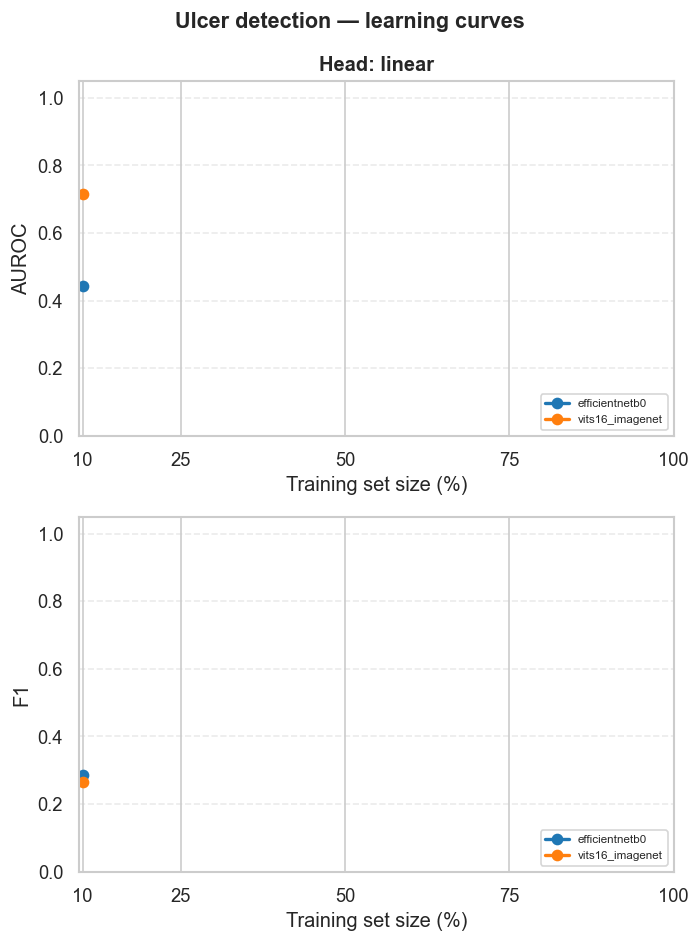

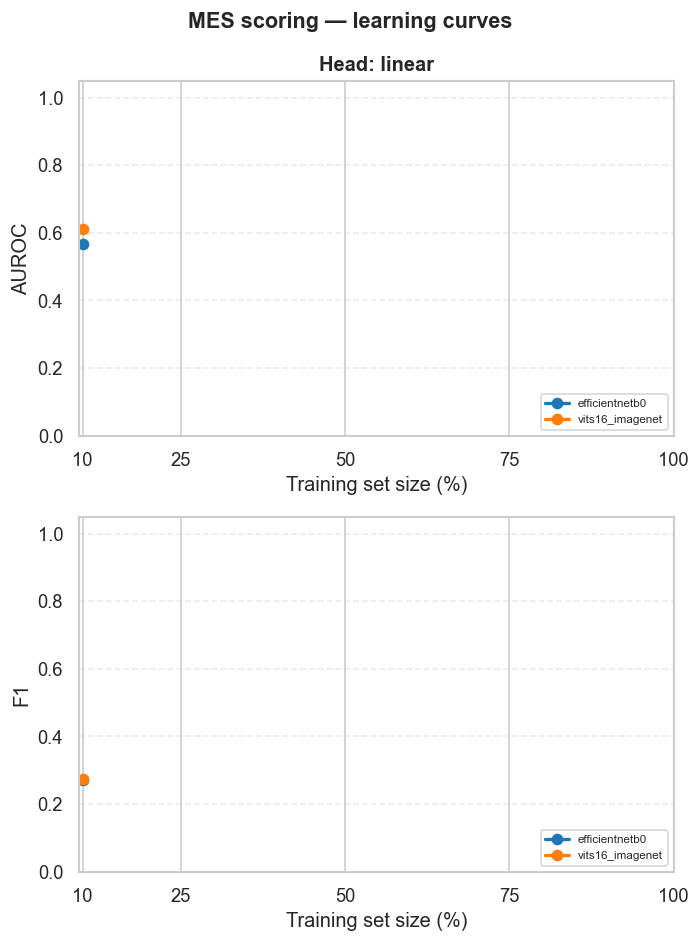

In [12]:
def plot_learning_curves_rich(
    df: pd.DataFrame,
    task: str,
    metrics: list[str] = ("auroc", "f1"),
    head_filter: list[str] | None = None,
    palette: str = "tab10",
) -> None:
    if df is None:
        return

    if head_filter:
        df = df[df["head_type"].isin(head_filter)]

    head_types = df["head_type"].unique()
    n_heads = len(head_types)
    n_metrics = len(metrics)

    fig, axes = plt.subplots(
        n_metrics, n_heads,
        figsize=(6 * n_heads, 4 * n_metrics),
        sharey="row", squeeze=False,
    )
    fig.suptitle(f"{task} — learning curves", fontsize=13, fontweight="bold")

    colors = plt.get_cmap(palette).colors
    models = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    for row_idx, metric in enumerate(metrics):
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"
        if mean_col not in df.columns:
            print(f"Column '{mean_col}' not found — skipping metric '{metric}'")
            continue

        for col_idx, head in enumerate(head_types):
            ax = axes[row_idx][col_idx]
            sub = df[df["head_type"] == head]

            for model_name, grp in sub.groupby("model"):
                grp = grp.sort_values("subset_ratio")
                x = grp["subset_ratio"] * 100
                y = grp[mean_col]
                y_std = grp[std_col] if std_col in grp.columns else 0
                color = color_map[model_name]

                (line,) = ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
                ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

            ax.set_title(f"Head: {head}" if row_idx == 0 else "", fontweight="bold")
            ax.set_xlabel("Training set size (%)")
            ax.set_ylabel(metric.upper() if col_idx == 0 else "")
            ax.set_xticks([10, 25, 50, 75, 100])
            ax.set_ylim(0, 1.05)
            ax.grid(axis="y", linestyle="--", alpha=0.4)
            ax.legend(loc="lower right", fontsize=7, frameon=True)

    fig.tight_layout()
    plt.show()

plot_learning_curves_rich(df_ulcer, "Ulcer detection", METRICS, HEAD_FILTER)
plot_learning_curves_rich(df_mes,   "MES scoring",     METRICS, HEAD_FILTER)

## 3. Per-Seed Raw Results

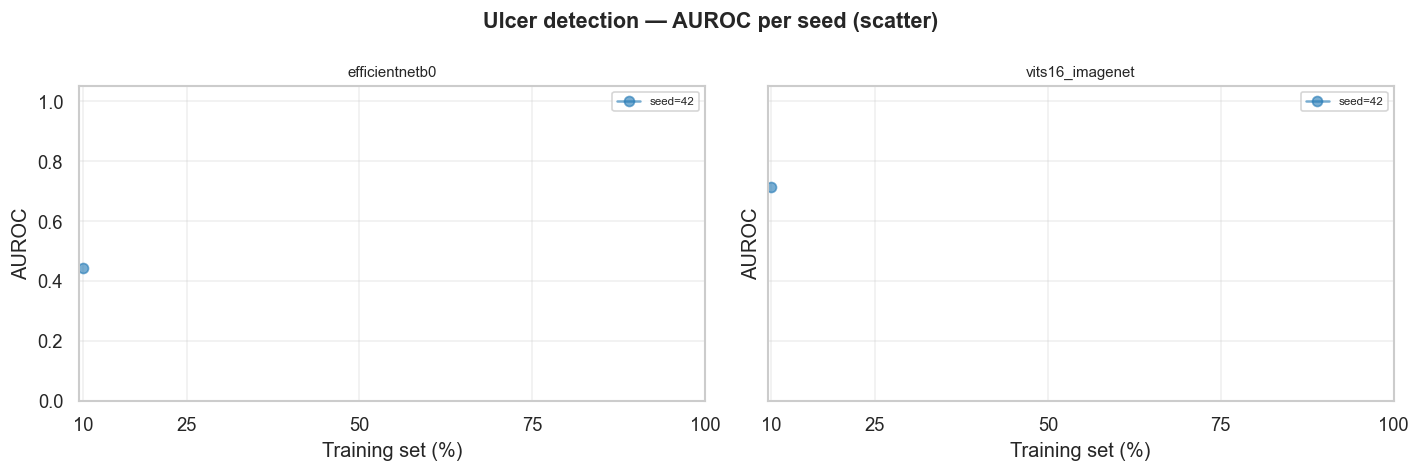

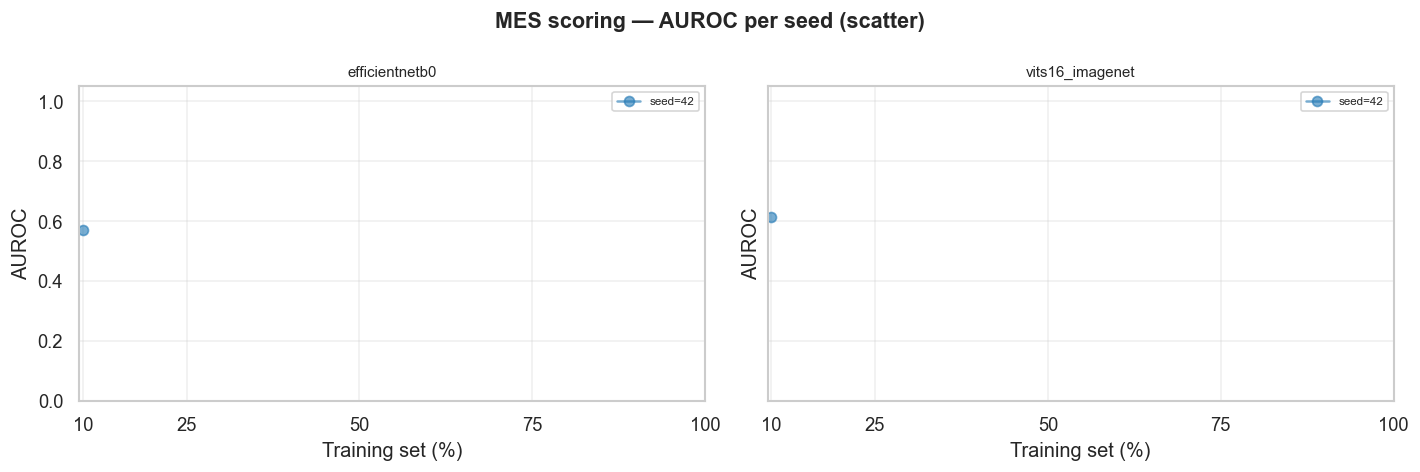

In [13]:
def plot_per_seed_scatter(
    path: Path,
    task: str,
    metric: str = "auroc",
    head_filter: list[str] | None = None,
) -> None:
    if not path.exists():
        print(f"[{task}] Per-seed file not found: {path}")
        return

    df = pd.read_csv(path)
    if head_filter:
        df = df[df["head_type"].isin(head_filter)]

    models = df["model"].unique()
    ncols = min(len(models), 3)
    nrows = (len(models) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True, squeeze=False)
    fig.suptitle(f"{task} — {metric.upper()} per seed (scatter)", fontsize=13, fontweight="bold")

    for idx, model_name in enumerate(models):
        ax = axes[idx // ncols][idx % ncols]
        mdf = df[df["model"] == model_name]
        for seed, sdf in mdf.groupby("seed"):
            sdf = sdf.sort_values("subset_ratio")
            ax.plot(sdf["subset_ratio"] * 100, sdf[metric], marker="o", alpha=0.6,
                    label=f"seed={seed}", linewidth=1.5)
        ax.set_title(model_name, fontsize=9)
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    for idx in range(len(models), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.tight_layout()
    plt.show()

plot_per_seed_scatter(ULCER_RAW, "Ulcer detection", metric="auroc", head_filter=HEAD_FILTER)
plot_per_seed_scatter(MES_RAW,   "MES scoring",     metric="auroc", head_filter=HEAD_FILTER)

## 4. Relative Gain vs Baseline

Show how much performance improves going from the smallest to the full dataset.

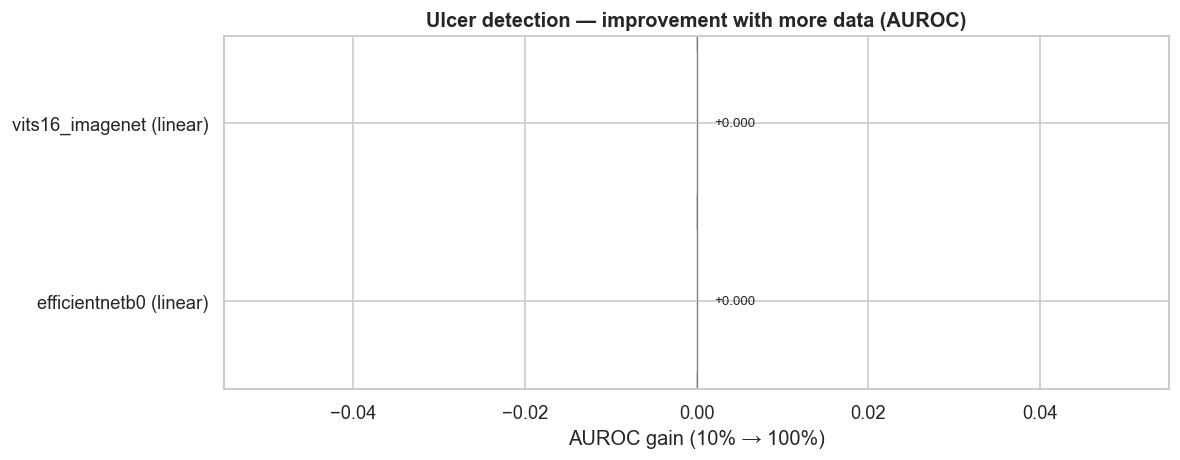

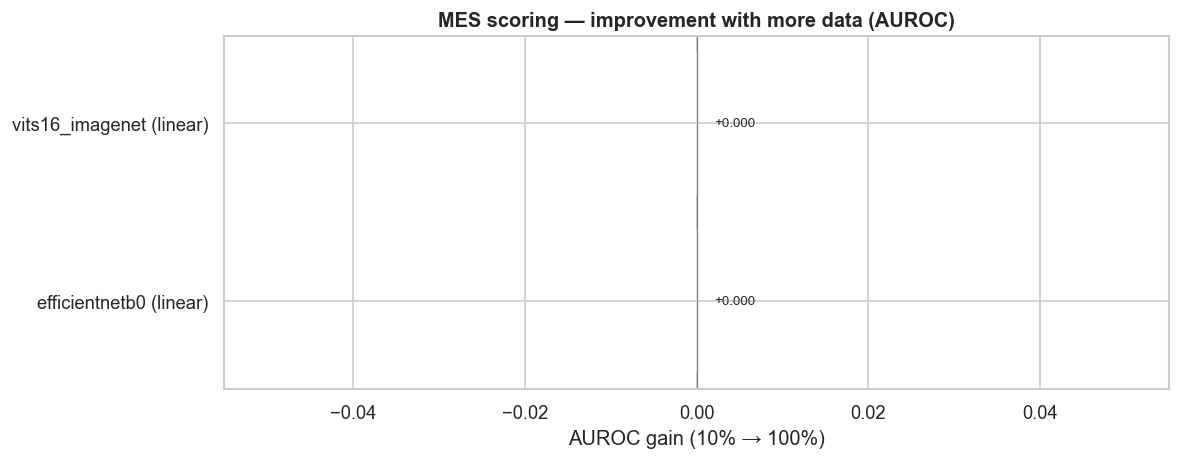

In [14]:
def plot_relative_gain(
    df: pd.DataFrame,
    task: str,
    metric: str = "auroc",
    baseline_ratio: float = 0.10,
) -> None:
    if df is None:
        return

    mean_col = f"{metric}_mean"
    if mean_col not in df.columns:
        return

    results = []
    for (model, head), grp in df.groupby(["model", "head_type"]):
        grp = grp.sort_values("subset_ratio")
        baseline_row = grp[grp["subset_ratio"].round(2) == round(baseline_ratio, 2)]
        full_row = grp[grp["subset_ratio"] == grp["subset_ratio"].max()]
        if baseline_row.empty or full_row.empty:
            continue
        baseline_val = baseline_row[mean_col].values[0]
        full_val = full_row[mean_col].values[0]
        gain = full_val - baseline_val
        results.append({"model": model, "head_type": head,
                        "baseline": baseline_val, "full": full_val, "gain": gain})

    if not results:
        print(f"[{task}] Could not compute relative gains (check subset ratios)")
        return

    rdf = pd.DataFrame(results).sort_values("gain", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(4, len(rdf) * 0.5)))
    colors = ["#2ecc71" if g > 0 else "#e74c3c" for g in rdf["gain"]]
    bars = ax.barh(rdf["model"] + " (" + rdf["head_type"] + ")", rdf["gain"], color=colors)
    for bar, row in zip(bars, rdf.itertuples()):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"+{row.gain:.3f}", va="center", fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(f"{metric.upper()} gain ({int(baseline_ratio*100)}% → 100%)")
    ax.set_title(f"{task} — improvement with more data ({metric.upper()})", fontweight="bold")
    fig.tight_layout()
    plt.show()

plot_relative_gain(df_ulcer, "Ulcer detection", metric="auroc")
plot_relative_gain(df_mes,   "MES scoring",     metric="auroc")

## 5. Ulcer vs MES Side-by-Side (if both available)

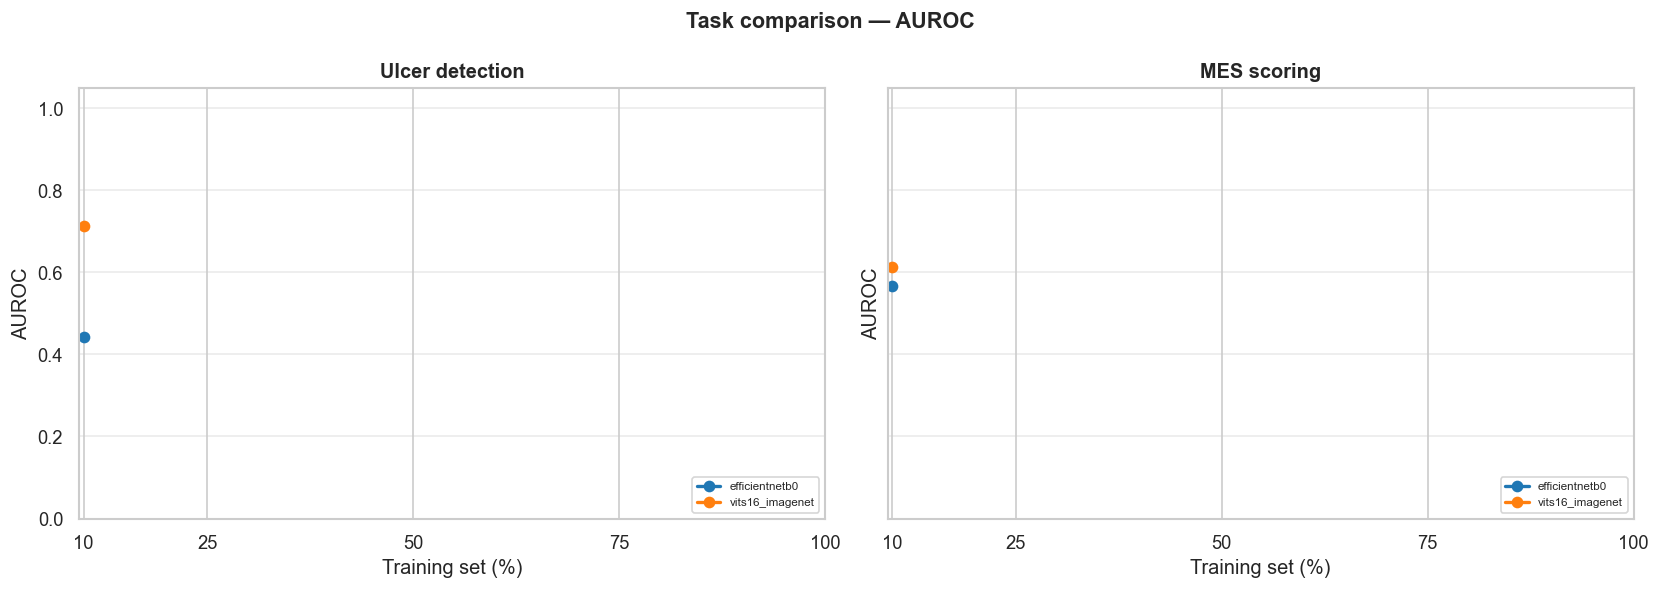

In [15]:
def plot_task_comparison(df_a: pd.DataFrame, label_a: str,
                          df_b: pd.DataFrame, label_b: str,
                          metric: str = "auroc",
                          head_filter: list[str] | None = None) -> None:
    if df_a is None or df_b is None:
        print("Both task results needed for comparison.")
        return

    mean_col = f"{metric}_mean"
    std_col  = f"{metric}_std"

    fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(f"Task comparison — {metric.upper()}", fontsize=13, fontweight="bold")

    colors = plt.get_cmap("tab10").colors

    for ax, df, label in [(ax_a, df_a, label_a), (ax_b, df_b, label_b)]:
        if head_filter:
            df = df[df["head_type"].isin(head_filter)]
        if mean_col not in df.columns:
            continue
        models = df["model"].unique()
        color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

        for model_name, grp in df.groupby("model"):
            grp = grp.sort_values("subset_ratio")
            x = grp["subset_ratio"] * 100
            y = grp[mean_col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)

        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(axis="y", alpha=0.4)
        ax.legend(loc="lower right", fontsize=7)

    fig.tight_layout()
    plt.show()

plot_task_comparison(df_ulcer, "Ulcer detection", df_mes, "MES scoring",
                     metric="auroc", head_filter=HEAD_FILTER)

## 6. MES-Specific: Clinical Metrics

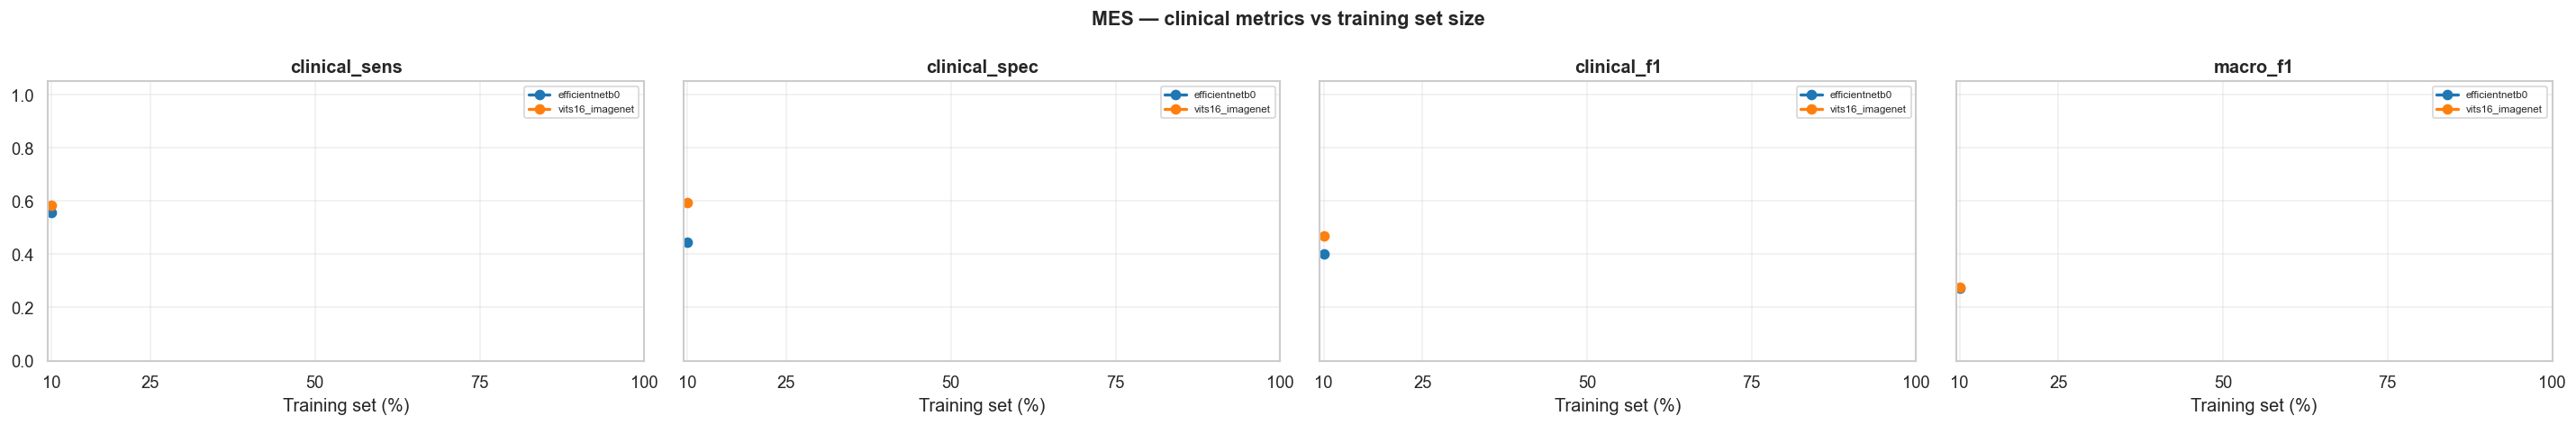

In [16]:
def plot_mes_clinical_metrics(df: pd.DataFrame) -> None:
    if df is None:
        return
    clinical_cols = [c for c in ("cli_sens_mean", "cli_spec_mean", "cli_f1_mean", "macro_f1_mean")
                     if c in df.columns]
    if not clinical_cols:
        print("No clinical MES columns found in results.")
        return

    fig, axes = plt.subplots(1, len(clinical_cols), figsize=(6 * len(clinical_cols), 4), sharey=True)
    if len(clinical_cols) == 1:
        axes = [axes]
    fig.suptitle("MES — clinical metrics vs training set size", fontsize=13, fontweight="bold")

    colors = plt.get_cmap("tab10").colors
    models = df["model"].unique()
    color_map = {m: colors[i % len(colors)] for i, m in enumerate(models)}

    for ax, col in zip(axes, clinical_cols):
        std_col = col.replace("_mean", "_std")
        for model_name, grp in df.groupby("model"):
            grp = grp.sort_values("subset_ratio")
            x = grp["subset_ratio"] * 100
            y = grp[col]
            y_std = grp[std_col] if std_col in grp.columns else 0
            color = color_map[model_name]
            ax.plot(x, y, marker="o", label=model_name, linewidth=2, color=color)
            ax.fill_between(x, y - y_std, y + y_std, color=color, alpha=0.15)
        ax.set_title(col.replace("_mean", "").replace("cli_", "clinical_"), fontweight="bold")
        ax.set_xlabel("Training set (%)")
        ax.set_ylim(0, 1.05)
        ax.set_xticks([10, 25, 50, 75, 100])
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.tight_layout()
    plt.show()

plot_mes_clinical_metrics(df_mes)